# Install dependencies

In [1]:
# Install dependencies
!pip install ultralytics matplotlib seaborn pandas opencv-python --quiet

In [2]:
from ultralytics import YOLO
import torch
import time
import os
import pandas as pd

device = 'cuda' if torch.cuda.is_available() else 'cpu'

models = {
    "YOLOv8n": YOLO("yolov8n.pt"),
    "YOLOv8s": YOLO("yolov8s.pt"),
    "YOLOv8m": YOLO("yolov8m.pt"),
    "YOLOv8l": YOLO("yolov8l.pt"),
}

# Dataset path

In [3]:
BASE_PATH = "homeobjects-3K"
DATASET_PATH = os.path.join(BASE_PATH, "HomeObjects-3K.yaml")

## Training

In [5]:
results = {}

for name, model in models.items():
    print(f"\n🚀 Training {name}")

    results[name] = model.train(
        data=DATASET_PATH,
        epochs=50,        # paper-ready (increase if needed)
        imgsz=640,
        batch=16,
        device=device,
        workers=4,
        verbose=False
    )


🚀 Training YOLOv8n
Ultralytics 8.4.45 🚀 Python-3.13.9 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 5090 Laptop GPU, 23984MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=homeobjects-3K/HomeObjects-3K.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-2, nbs=64, nms=False, opset=None, optimize=False,

## Accuracy Matrices

In [6]:
metrics = []

for name, model in models.items():
    val = model.val()

    metrics.append({
        "Model": name,
        "mAP50": val.box.map50,
        "mAP50-95": val.box.map,
        "Precision": val.box.mp,
        "Recall": val.box.mr
    })

df_metrics = pd.DataFrame(metrics)
df_metrics

Ultralytics 8.4.45 🚀 Python-3.13.9 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 5090 Laptop GPU, 23984MiB)
Model summary (fused): 73 layers, 3,007,988 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 4642.0±2179.8 MB/s, size: 106.5 KB)
val: Scanning /home/raviraj/homeobjects-3K/labels/val.cache... 404 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 404/404 242.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 26/26 19.0it/s 1.4s0.1s
                   all        404       3470      0.709      0.608      0.686      0.484
                   bed         22         22      0.584      0.682      0.719      0.488
                  sofa        286        398      0.885      0.724      0.854      0.641
                 chair        154        305      0.691      0.695      0.733      0.503
                 table        300        469      0.776      0.708      0.807      0.586
      

,Model,mAP50,mAP50-95,Precision,Recall
0,YOLOv8n,0.686218,0.483821,0.708573,0.608274
1,YOLOv8s,0.722187,0.525716,0.719047,0.693718
2,YOLOv8m,0.742039,0.546220,0.744868,0.685732
3,YOLOv8l,0.738929,0.545254,0.749905,0.679607


## Speed and FPS benchmark

In [7]:
import numpy as np

speed_results = []

sample_img = os.path.join(BASE_PATH, "images", "val", os.listdir(os.path.join(BASE_PATH, "images", "val"))[0])

for name, model in models.items():

    # warmup
    _ = model(sample_img)

    times = []

    for _ in range(50):
        start = time.time()
        _ = model(sample_img)
        end = time.time()
        times.append(end - start)

    avg_time = np.mean(times)
    fps = 1 / avg_time

    speed_results.append({
        "Model": name,
        "Latency (s)": avg_time,
        "FPS": fps
    })

df_speed = pd.DataFrame(speed_results)
df_speed


image 1/1 /home/raviraj/homeobjects-3K/images/val/living_room_327.jpg: 640x448 1 chair, 1 table, 2 potted plants, 2 photo frames, 13.7ms
Speed: 3.4ms preprocess, 13.7ms inference, 2.7ms postprocess per image at shape (1, 3, 640, 448)

image 1/1 /home/raviraj/homeobjects-3K/images/val/living_room_327.jpg: 640x448 1 chair, 1 table, 2 potted plants, 2 photo frames, 3.2ms
Speed: 1.4ms preprocess, 3.2ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 448)

image 1/1 /home/raviraj/homeobjects-3K/images/val/living_room_327.jpg: 640x448 1 chair, 1 table, 2 potted plants, 2 photo frames, 2.5ms
Speed: 1.2ms preprocess, 2.5ms inference, 3.9ms postprocess per image at shape (1, 3, 640, 448)

image 1/1 /home/raviraj/homeobjects-3K/images/val/living_room_327.jpg: 640x448 1 chair, 1 table, 2 potted plants, 2 photo frames, 2.3ms
Speed: 1.2ms preprocess, 2.3ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 448)

image 1/1 /home/raviraj/homeobjects-3K/images/val/living_room_327

,Model,Latency (s),FPS
0,YOLOv8n,0.009692,103.179083
1,YOLOv8s,0.009393,106.462955
2,YOLOv8m,0.010771,92.840674
3,YOLOv8l,0.012656,79.011929


## Model size

In [8]:
size_results = []

for name, model in models.items():
    weight_path = model.ckpt_path if hasattr(model, "ckpt_path") else model.model_name

    size_mb = os.path.getsize(weight_path) / (1024 * 1024)

    size_results.append({
        "Model": name,
        "Size (MB)": size_mb
    })

df_size = pd.DataFrame(size_results)
df_size

,Model,Size (MB)
0,YOLOv8n,6.246372
1,YOLOv8s,21.542332
2,YOLOv8m,49.721607
3,YOLOv8l,83.725773


In [9]:
final_df = df_metrics.merge(df_speed, on="Model").merge(df_size, on="Model")

final_df

,Model,mAP50,mAP50-95,Precision,Recall,Latency (s),FPS,Size (MB)
0,YOLOv8n,0.686218,0.483821,0.708573,0.608274,0.009692,103.179083,6.246372
1,YOLOv8s,0.722187,0.525716,0.719047,0.693718,0.009393,106.462955,21.542332
2,YOLOv8m,0.742039,0.546220,0.744868,0.685732,0.010771,92.840674,49.721607
3,YOLOv8l,0.738929,0.545254,0.749905,0.679607,0.012656,79.011929,83.725773


## Prediction Visualization

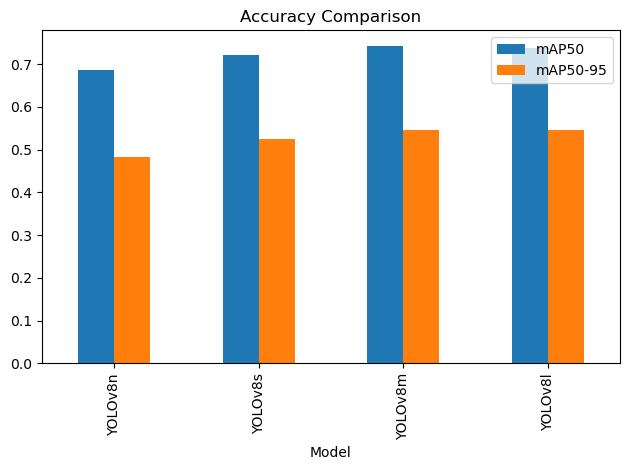

In [40]:
%matplotlib inline
import matplotlib.pyplot as plt

final_df.plot(x="Model", y=["mAP50", "mAP50-95"], kind="bar")
plt.title("Accuracy Comparison")
plt.tight_layout()
plt.savefig("results/map50_vs_epoch.png", dpi=300)
plt.show()

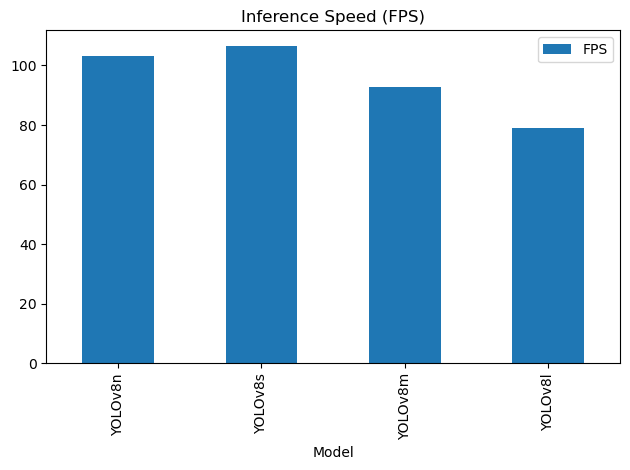

In [43]:
final_df.plot(x="Model", y="FPS", kind="bar")
plt.title("Inference Speed (FPS)")
plt.tight_layout()
plt.savefig("results/map50_vs_epoch.png", dpi=300)
plt.show()

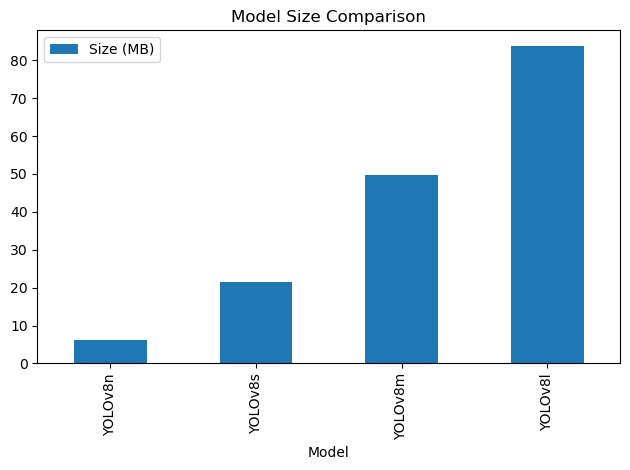

In [45]:
final_df.plot(x="Model", y="Size (MB)", kind="bar")
plt.title("Model Size Comparison")
plt.tight_layout()
plt.savefig("results/map50_vs_epoch.png", dpi=300)
plt.show()

In [36]:
import glob

result_files = glob.glob("runs/detect/train*/results.csv")
print(result_files)

['runs/detect/train-4/results.csv', 'runs/detect/train-5/results.csv', 'runs/detect/train-2/results.csv', 'runs/detect/train-3/results.csv']


## PR Curve & Confusion Matrix

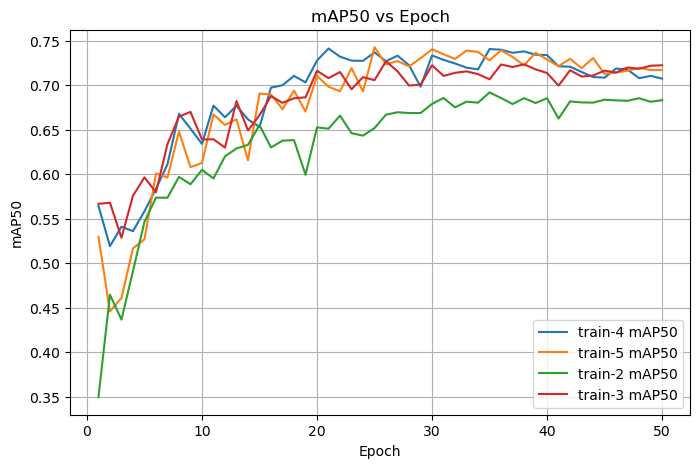

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import os

plt.figure(figsize=(8,5))

for file in result_files:
    df = pd.read_csv(file)

    # Extract model name from folder
    model_name = os.path.basename(os.path.dirname(file))

    # Plot mAP50
    plt.plot(df['epoch'], df['metrics/mAP50(B)'], label=f"{model_name} mAP50")

plt.xlabel("Epoch")
plt.ylabel("mAP50")
plt.title("mAP50 vs Epoch")
plt.legend()
plt.grid()

plt.savefig("results/map.png", dpi=300)
plt.show()

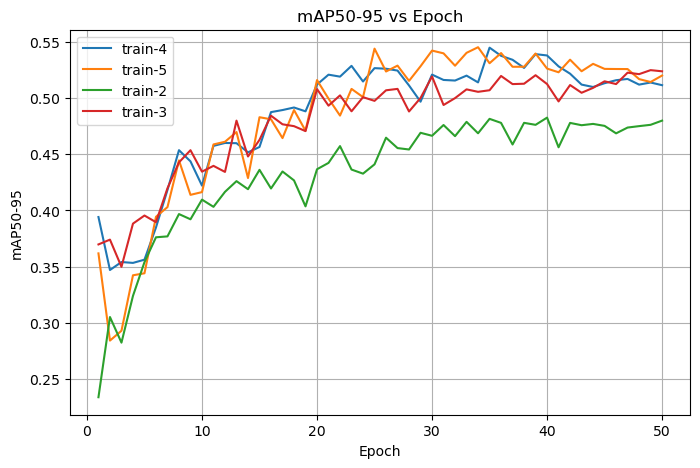

In [38]:
plt.figure(figsize=(8,5))

for file in result_files:
    df = pd.read_csv(file)
    model_name = os.path.basename(os.path.dirname(file))

    plt.plot(df['epoch'], df['metrics/mAP50-95(B)'], label=model_name)

plt.xlabel("Epoch")
plt.ylabel("mAP50-95")
plt.title("mAP50-95 vs Epoch")
plt.legend()
plt.grid()

plt.savefig("results/map5095.png", dpi=300)
plt.show()